# Randomization Comparison

This notebook analyzes how the number of randomized runs affects solution quality and run time of the final local-search configuration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

In [2]:
MAX_RUNS = 50
RUN_COUNTS = list(range(1, MAX_RUNS + 1))
DISPLAY_RUN_COUNTS = [1, *range(5, MAX_RUNS + 1, 5)]

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

GRAPH_TYPE_LABELS = {
    "powerlaw": "Powerlaw",
    "er": "Erdős–Rényi",
}

PIPELINE = ",".join(["move_plateau"] * 4)
START_PARTITION = "maximum_matching"
ZERO_GAIN_FACTOR = 4

RESULTS_DIR = Path("../../results/experiment2/independent_runs")
RAW_RESULTS_FILE = RESULTS_DIR / "raw_results.csv"

PLOTS_DIR = RESULTS_DIR.parents[1] / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [3]:
raw = pd.read_csv(RAW_RESULTS_FILE)

raw["dataset_group"] = raw["size_class"].astype(str) + " " + raw["regime"].astype(str)

raw["graph_type"] = pd.Categorical(
    raw["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

raw["dataset_group"] = pd.Categorical(
    raw["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

raw = raw[(raw["pipeline"] == PIPELINE) & (raw["start_partition"] == START_PARTITION) & (raw["zero_gain_factor"] == ZERO_GAIN_FACTOR)].copy()

run_order = {run: i + 1 for i, run in enumerate(sorted(raw["run"].unique()))}

raw["run_number"] = raw["run"].map(run_order)

## Solution quality

For every instance and number of randomized runs $k$, the best solution obtained among the first $k$ runs is retained.

The best solution obtained across all 50 runs serves as the reference. Relative solution quality for $k$ runs is defined as

$
\frac{\text{best score across all 50 runs}}
     {\text{best score across the first }k\text{ runs}}.
$

A value of $1.0$ indicates that the first $k$ randomized runs already contain the best solution found across all 50 runs. Values greater than $1.0$ indicate the remaining quality gap.

In [4]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

raw = (
    raw
    .sort_values(instance_keys + ["run_number"])
    .reset_index(drop=True)
)

raw["best_density_so_far"] = (
    raw
    .groupby(instance_keys, observed=True)["final_density"]
    .cummax()
)

run_scores = (
    raw
    .pivot( index=instance_keys, columns="run_number", values="best_density_so_far")
    .reindex(columns=RUN_COUNTS)
)

reference_score = run_scores[MAX_RUNS]
relative_quality = run_scores.rdiv(reference_score, axis=0)

relative_quality.columns.name = "num_runs"

relative_quality_summary = (
    relative_quality
    .groupby(level=["graph_type", "dataset_group"])
    .mean()
    .stack()
    .rename("mean_relative_quality")
    .reset_index()
)

relative_quality_summary = relative_quality_summary[relative_quality_summary["num_runs"].isin(DISPLAY_RUN_COUNTS)]

relative_quality_summary

,graph_type,dataset_group,num_runs,mean_relative_quality
0,powerlaw,small sparse,1,1.009041
4,powerlaw,small sparse,5,1.003504
9,powerlaw,small sparse,10,1.002068
14,powerlaw,small sparse,15,1.001529
19,powerlaw,small sparse,20,1.001098
...,...,...,...,...
379,er,large dense,30,1.001034
384,er,large dense,35,1.000622
389,er,large dense,40,1.000389
394,er,large dense,45,1.000249


## Relative solution quality

The figures show how mean relative solution quality develops as the number of randomized runs increases. The result obtained from all 50 runs serves as the reference.

In [5]:
def plot_relative_quality(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "num_runs"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["num_runs"],
            group_data["mean_relative_quality"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="50 runs",
    )

    ax.set_xlabel("Number of randomized runs")
    ax.set_ylabel("Mean relative solution quality")
    ax.set_title(f"Relative solution quality ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(DISPLAY_RUN_COUNTS)

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

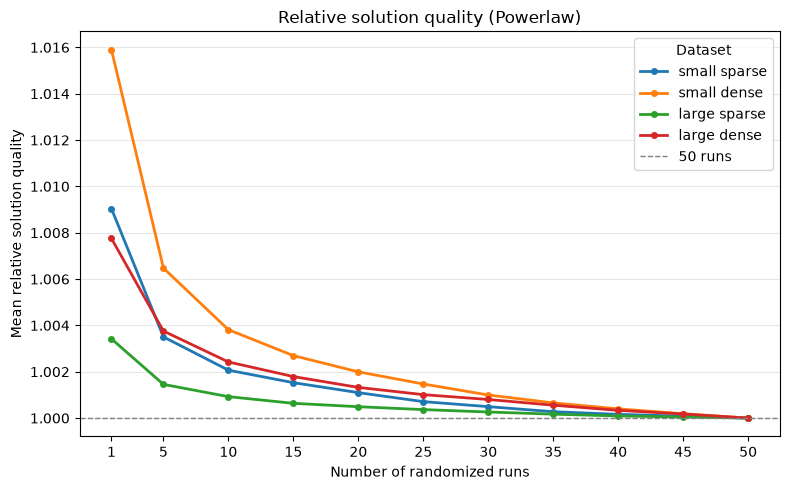

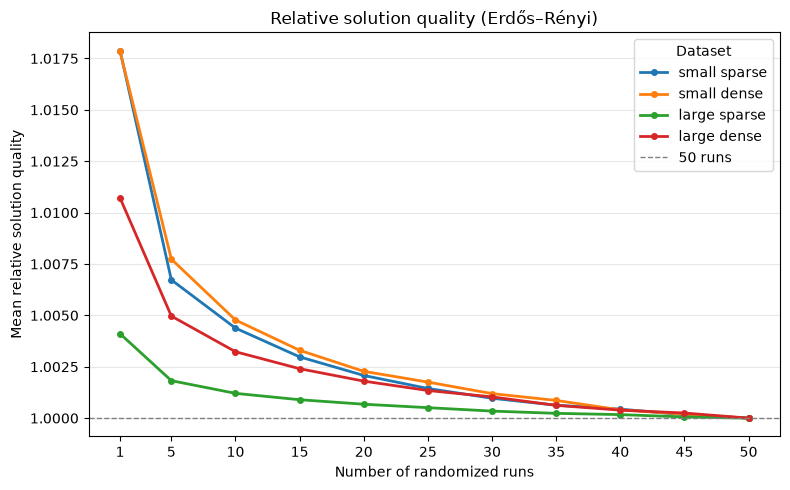

In [6]:
plot_relative_quality(
    relative_quality_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_randomization_quality.png",
)

plot_relative_quality(
    relative_quality_summary,
    "er",
    PLOTS_DIR / "er_randomization_quality.png",
)

## Run time

For every instance, the run times are accumulated in execution order. The cumulative run time after \(k\) runs therefore represents the total computational effort of these \(k\) randomized executions.

In [7]:
raw["cumulative_runtime"] = (
    raw
    .groupby(instance_keys, observed=True)["ls_runtime"]
    .cumsum()
)

runtime_summary = (
    raw
    .groupby(["graph_type", "dataset_group", "run_number"], observed=True, as_index=False)
    .agg(mean_total_runtime=("cumulative_runtime", "mean"))
    .rename(columns={"run_number": "num_runs"})
)

runtime_summary = runtime_summary[runtime_summary["num_runs"].isin(DISPLAY_RUN_COUNTS)]

runtime_summary

,graph_type,dataset_group,num_runs,mean_total_runtime
0,powerlaw,small sparse,1,1.895455
4,powerlaw,small sparse,5,9.515276
9,powerlaw,small sparse,10,19.187016
14,powerlaw,small sparse,15,28.854973
19,powerlaw,small sparse,20,38.424403
...,...,...,...,...
379,er,large dense,30,1131.202059
384,er,large dense,35,1312.631569
389,er,large dense,40,1494.890796
394,er,large dense,45,1674.131272


## Run time development

The figures show how the mean total run time increases with the number of randomized runs.

In [8]:
def plot_total_runtime(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "num_runs"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["num_runs"],
            group_data["mean_total_runtime"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=dataset_group,
        )

    ax.set_xlabel("Number of randomized runs")
    ax.set_ylabel("Mean total run time (s)")
    ax.set_title(f"Total run time ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(DISPLAY_RUN_COUNTS)

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

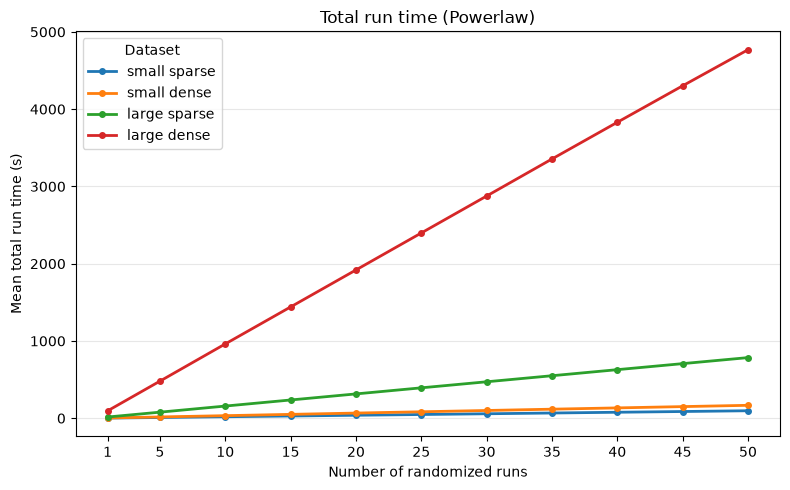

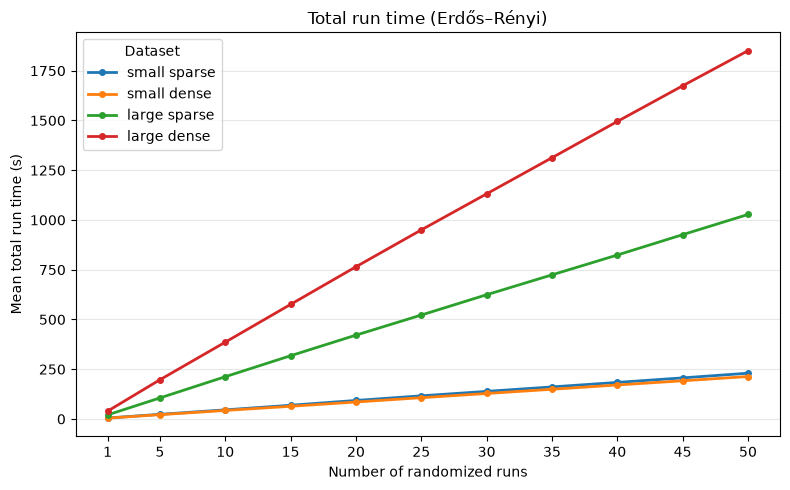

In [9]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_randomization_runtime.png",
)

plot_total_runtime(
    runtime_summary,
    "er",
    PLOTS_DIR / "er_randomization_runtime.png",
)